<a href="https://colab.research.google.com/github/scottac1111/Alex-Scott-Repository/blob/main/coding_homework_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####Alex Scott
*NEUR 265*

**4/10/26**

In [16]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr



In [11]:
# Import files as numpy arrays

url1 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv'
fear_traces = np.loadtxt (url1, delimiter = ',')

url2 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv'
extinction_predictors = np.loadtxt (url2, delimiter = ',')

url3 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv'
shock_index = np.loadtxt (url3, delimiter = ',').astype(int)

url4 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv'
tone_index = np.loadtxt (url4, delimiter =',').astype(int)


In [3]:
# Split traces into conditioning and extinction

conditioning_traces = fear_traces[:10458, :]
extinction_traces = fear_traces[10458:, :]

In [4]:
# Print size

print(conditioning_traces.shape)
print(extinction_traces.shape)

(10458, 63)
(14210, 63)


In [5]:
# Create time arrays

time_conditioning = np.arange(conditioning_traces.shape[0]) / 15
time_extinction = np.arange(extinction_traces.shape[0]) / 15

In [6]:
# Number of ROIs
num_rois = conditioning_traces.shape[1]

# Conditioning time
cond_seconds = conditioning_traces.shape[0] / 15
cond_minutes = cond_seconds / 60

# Extinction time
ext_seconds = extinction_traces.shape[0] / 15
ext_minutes = ext_seconds / 60

# Print results
print("ROIs:", num_rois)

print("Conditioning:")
print("Seconds:", cond_seconds)
print("Minutes:", cond_minutes)

print("Extinction:")
print("Seconds:", ext_seconds)
print("Minutes:", ext_minutes)

ROIs: 63
Conditioning:
Seconds: 697.2
Minutes: 11.620000000000001
Extinction:
Seconds: 947.3333333333334
Minutes: 15.78888888888889


The dataset contains 63 ROIs (cells).

The conditioning session lasted 697.2 seconds (11.62 minutes).

The extinction session lasted 947.33 seconds (15.79 minutes).

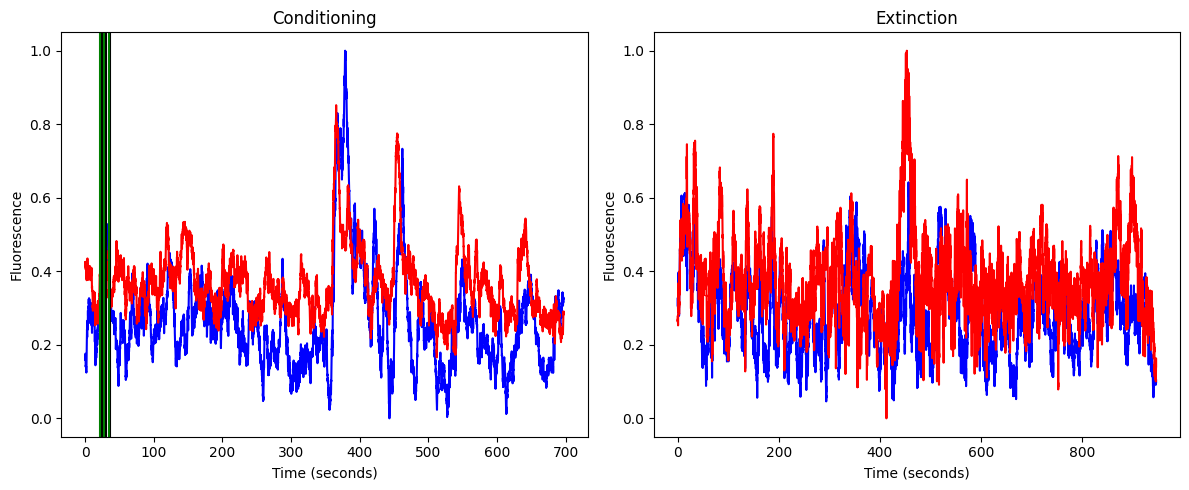

In [7]:
# Plot first and second ROIs for conditioning and extinction

plt.figure(figsize=(12,5))

# Conditioning subplot
plt.subplot(1,2,1)

# Plot ROI 1 (blue) and ROI 2 (red)
plt.plot(time_conditioning, conditioning_traces[:,0], color='blue')
plt.plot(time_conditioning, conditioning_traces[:,1], color='red')

# Add vertical lines for shock onset (black)
for s in shock_index:
    plt.axvline(x=s/15, color='black')

# Add vertical lines for tone onset (green)
for t in tone_index:
    plt.axvline(x=t/15, color='green')

plt.title("Conditioning")
plt.xlabel("Time (seconds)")
plt.ylabel("Fluorescence")

# Extinction subplot
plt.subplot(1,2,2)

# Plot ROI 1 (blue) and ROI 2 (red)
plt.plot(time_extinction, extinction_traces[:,0], color='blue')
plt.plot(time_extinction, extinction_traces[:,1], color='red')

plt.title("Extinction")
plt.xlabel("Time (seconds)")
plt.ylabel("Fluorescence")

plt.tight_layout()
plt.show()

In the plotted data, ROI 1 (blue) and ROI 2 (red) show different response patterns during both conditioning and extinction. For example, during conditioning, both ROIs show activity changes that appear to align with tone and shock onset, but the strength and timing of these responses are not identical between the two cells. This suggests that the two ROIs are not encoding the stimulus in exactly the same way.

During extinction, both ROIs show reduced and less consistent activity compared to conditioning.

From a mere observation of the blue and red traces during conditioning, there seems to be more frequent overlapping which tells me that the two cells sometimes respond at similar times to tone and shock onset. This suggests that both cells are more strongly driven by the same task related events during learning.

In contrast, during extinction, the overlap between the two traces appears reduced, with fewer synchronized peaks and more independent activity patterns. This indicates that the cells are responding less similarly to the same stimuli when the shock is no longer present.

In [20]:
from pandas import DataFrame as df

# Build shock array
shock_array = np.zeros(conditioning_traces.shape[0])
for i in range(conditioning_traces.shape[0]):
    if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
        shock_array[i] = 1
    elif i >= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
        shock_array[i] = 1
    elif i >= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
        shock_array[i] = 1

# Build tone array
tone_array = np.zeros(conditioning_traces.shape[0])
for i in range(conditioning_traces.shape[0]):
    if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
        tone_array[i] = 1
    elif i >= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
        tone_array[i] = 1
    elif i >= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
        tone_array[i] = 1

# Predictors DataFrame
predictors_conditioning = df({
    'Intercept': np.ones_like(tone_array),
    'shock onset': shock_array,
    'tone onset': tone_array
})

In [28]:
import statsmodels.api as sm


# Initialize array to store correlation values (one per ROI)
r_index_conditioning = np.zeros(conditioning_traces.shape[1])

# Loop through ALL ROIs
for i in range(conditioning_traces.shape[1]):

    # Extract single ROI trace
    trace_temp = conditioning_traces[:, i]

    # Run GLM using predictors
    model = sm.GLM(trace_temp, predictors_conditioning, family=sm.families.Poisson())
    model_results = model.fit()

    # Get predicted trace
    predicted_trace = model_results.predict()

    # Compute correlation between actual and predicted
    r = pearsonr(trace_temp, predicted_trace)

    # Store correlation value
    r_index_conditioning[i] = r[0]

In [26]:

from pandas import DataFrame as df

tone_ext = np.zeros(extinction_traces.shape[0])

for i in range(extinction_traces.shape[0]):
    if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
        tone_ext[i] = 1
    elif i >= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
        tone_ext[i] = 1
    elif i >= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
        tone_ext[i] = 1

predictors_extinction = df({
    'Intercept': np.ones_like(tone_ext),
    'tone onset': tone_ext
})

# Initialize array to store extinction correlations
r_index_extinction = np.zeros(extinction_traces.shape[1])

# Loop through ALL ROIs in extinction data
for i in range(extinction_traces.shape[1]):

    # Extract single ROI trace
    trace_temp = extinction_traces[:, i]


    # Run GLM using extinction predictors
    model = sm.GLM(trace_temp, predictors_extinction, family=sm.families.Poisson())
    model_results = model.fit()

    # Predicted trace
    predicted_trace = model_results.predict()

    # Correlate actual vs predicted
    r = pearsonr(trace_temp, predicted_trace)

    # Store correlation value
    r_index_extinction[i] = r[0]

In [30]:
# Use pearsonr function to correlate

r_total, p_value = pearsonr(r_index_conditioning, r_index_extinction)

print("Correlation (r):", r_total)
print("p-value:", p_value)

Correlation (r): 0.1261968889101202
p-value: 0.3243560127180143


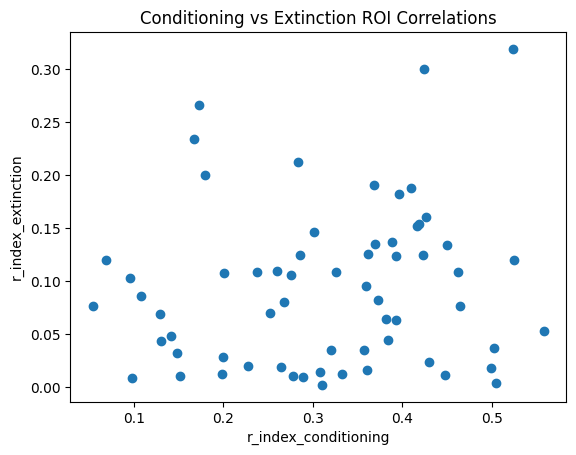

In [31]:
# Make scatterplot

plt.scatter(r_index_conditioning, r_index_extinction)

plt.xlabel("r_index_conditioning")
plt.ylabel("r_index_extinction")
plt.title("Conditioning vs Extinction ROI Correlations")

plt.show()

The correlation between r_index_conditioning and r_index_extinction is weak (r = 0.13) and not statistically significant (p > 0.05). What this tells me is that there is little to no reliable relationship between how strongly a cell responds during conditioning and how strongly it responds during extinction.

The scatter plot also confirms this since the points are widely dispersed without a clear upward trend, which is indicative of a weak correlation. This suggests that cells that respond strongly to shock and tone onset during the conditioning session are not necessarily more likely to respond strongly to tone onset during the extinction session.